# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
import unicodedata
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
import spacy
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [3]:
#FUNCIONES DE LIMPIEZA DE TEXTO
def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)

    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas

def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado

In [ ]:
carpeta = 'C:/Users/Desktop/caso_08'
textos_victimas = []
textos_manzur = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        archivo_norm = unidecode(archivo.lower())
        archivo_norm = archivo_norm.replace(',', '').replace('-', ' ').replace('_', ' ')

        if 'villavicencio' in archivo_norm:
            textos_victimas.append((archivo, contenido))
        else:
            textos_manzur.append((archivo, contenido))

texto_victimas = ' '.join([contenido for _, contenido in textos_victimas])
texto_manzur = ' '.join([contenido for _, contenido in textos_manzur])
texto_manzur = texto_manzur.replace("mansur", "manzur")
texto_manzur = texto_manzur.replace("Mansur", "manzur")
texto_manzur = texto_manzur.replace("Leiva", "leyva")
texto_manzur = texto_manzur.replace("leiva", "leyva")

print(f"Archivos de Manzur: {len(textos_manzur)}")
print(f"Archivos de victimas: {len(textos_victimas)}")


Archivos de Manzur: 2
Archivos de victimas: 1


In [ ]:
#Realizar una primera lematización con terminos reconocidos (por ej. algunos adverbios)
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)

textos = {
    'Audiencia víctimas': texto_victimas,
    'Julio Alberto Manzur Abdala': texto_manzur}
textos_lematizados = {}

for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)
texto_victimas_lem = textos_lematizados['Audiencia víctimas']
texto_manzur_lem = textos_lematizados['Julio Alberto Manzur Abdala']


#Eliminar palabras cortas:
texto_victimas_final = eliminar_palabras_cortas(texto_victimas_lem)
texto_manzur_final = eliminar_palabras_cortas(texto_manzur_lem)

# tokenizar
textos = {
    'Audiencia Víctimas': texto_victimas_final,'Julio Alberto Manzur Abdala': texto_manzur_final}
tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens

# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# Lematización con spacy
excepciones = {"voluntaria", "soldado"}
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser", "ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas

lemas_dict = {}
for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas_dict[nombre] = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
# Reconstruir cada texto:
textos_lemas = {
    nombre: " ".join(lemas_dict[nombre])
    for nombre in ["Audiencia Víctimas", "Julio Alberto Manzur Abdala"]}

#emplear lematizacion anterior:
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_08.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()
textos_finales_dicc = {}

for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)  # si no está en el diccionario, se deja igual

    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final

In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ---------------------------- Stopwords ---------------------------------
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))

# ---------------   -Diccionarios de términos y lemas adicionales ---------------
ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

# ------------------------- Limpiar texto -----------------------------------------
textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)

textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# ------------------------ Generar skipgramas ----------------------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas}

# **GENERAR SKIPGRAMAS**

In [12]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]
#Filtrar skipgramas:
    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Audiencia Víctimas':


,Skipgrama,Frecuencia
0,jurisdiccion especial,45
1,desaparicion forzar,45
2,version voluntario,42
3,especial paz,42
4,jurisdiccion paz,41
5,fuerza publico,38
6,ministerio publico,27
7,persona desaparecer,24
8,victima acreditar,20
9,miembro fuerza,19



Top 10 skipgramas en 'Julio Alberto Manzur Abdala':


,Skipgrama,Frecuencia
0,departamento cordoba,261
1,jaime garcia,96
2,carlos castano,76
3,fondo ganadero,63
4,luis carlos,62
5,corte justicia,59
6,corte suprema,58
7,suprema justicia,55
8,justicia paz,46
9,hoja vida,44


# **ANÁLISIS DESCRIPTIVO**

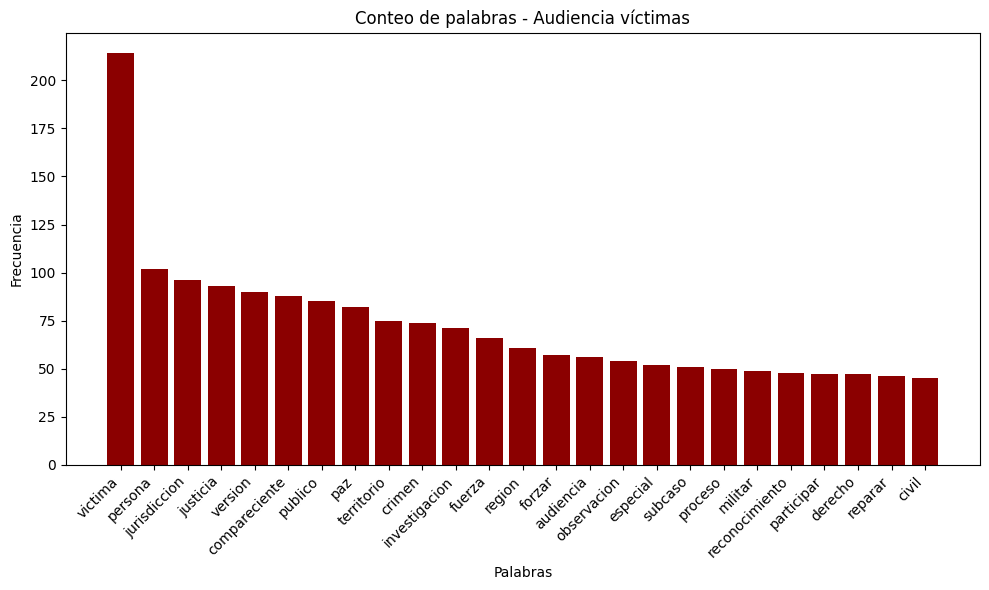

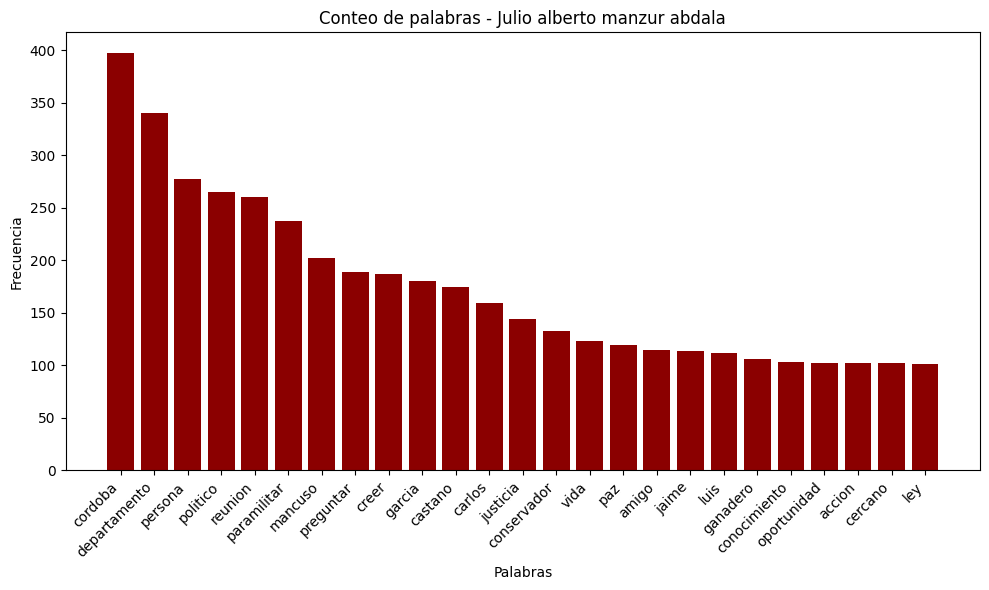

In [13]:
##Distribución de frecuencias
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias
    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)
tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)


 Frecuencias para: Audiencia Víctimas
          Palabra  Frecuencia
0         victima         214
1         persona         102
2    jurisdiccion          96
3        justicia          93
4         version          90
5   compareciente          88
6         publico          85
7             paz          82
8      territorio          75
9          crimen          74
10  investigacion          71
11         fuerza          66
12         region          61
13         forzar          57
14      audiencia          56

 Frecuencias para: Julio Alberto Manzur Abdala
         Palabra  Frecuencia
0        cordoba         397
1   departamento         340
2        persona         277
3       politico         265
4        reunion         260
5    paramilitar         237
6        mancuso         202
7      preguntar         189
8          creer         187
9         garcia         180
10       castano         175
11        carlos         159
12      justicia         144
13   conservador         13

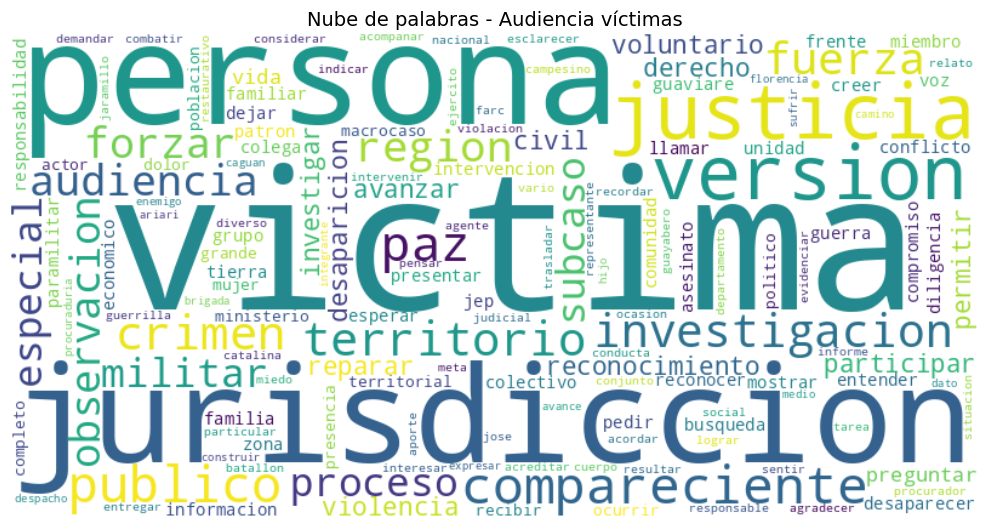

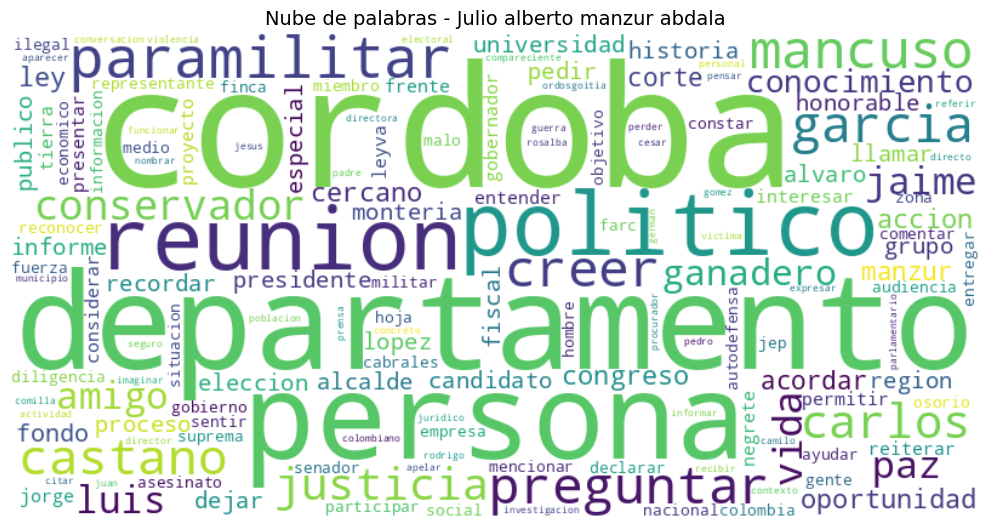

In [15]:
#  Crear nube de palabras para cada grupo de análisis
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()

# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())


                         Texto  Positivo  Negativo   Ira  Anticipación  \
0           Audiencia Víctimas      2280      1257   881           857   
1  Julio Alberto Manzur Abdala      4344      1981  1059          1855   

   Disgusto  Miedo  Alegría  Tristeza  Sorpresa  Confianza  
0       349   1016      493       746       383       1302  
1       839   1281      949      1177       616       3088  


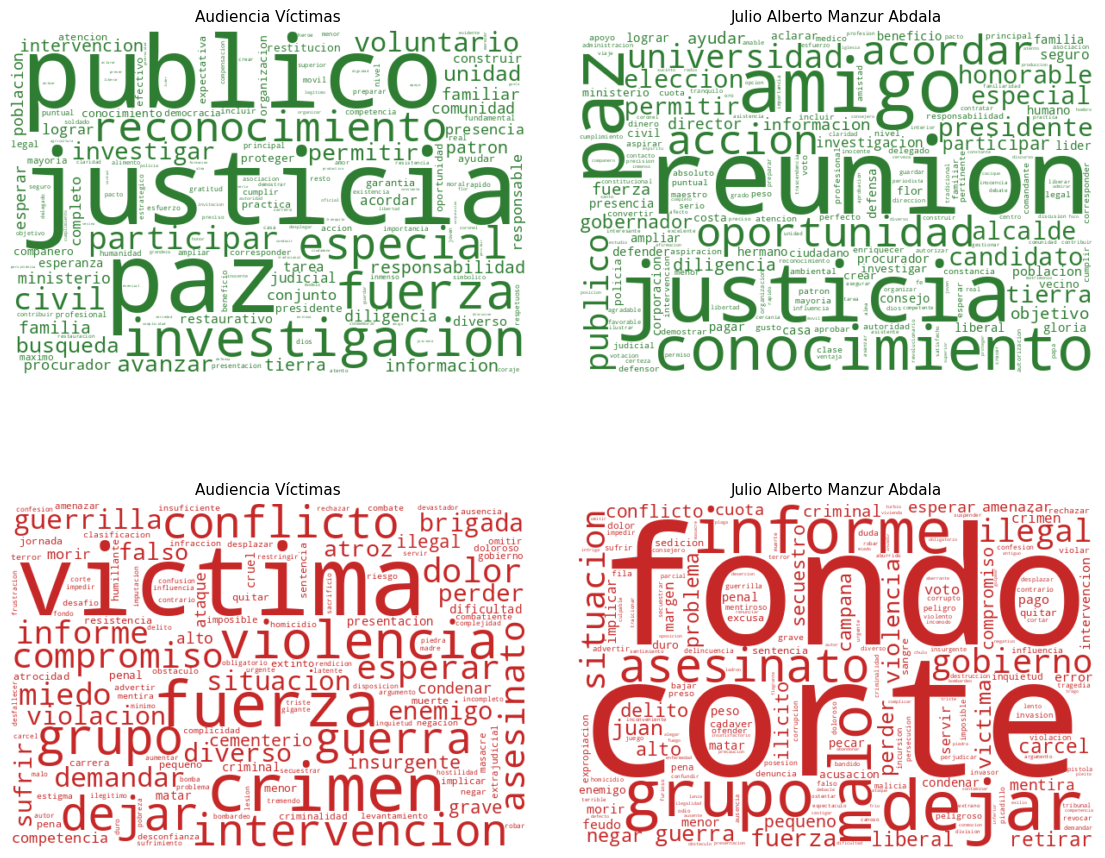

In [ ]:
##Nube de palabras de términos positivos y negativos empleando diccionario NRC
def limpiar_palabra(p):
    if pd.isna(p):
        return ""
    p = unidecode(str(p).lower().strip())
    p = re.sub(r'[^a-zñáéíóúü\s]', '', p)
    p = re.sub(r'\s+', ' ', p)
    return p

lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})
lexico['Palabra'] = lexico['Palabra'].apply(limpiar_palabra)

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation',
    'Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()

positivas = set(lexico.loc[lexico['Positive'] > 0, 'Palabra'])
negativas = set(lexico.loc[lexico['Negative'] > 0, 'Palabra'])

verde_fijo = "#2E7D32"   
rojo_fijo  = "#C62828"  

def color_verde(*args, **kwargs):
    return verde_fijo

def color_rojo(*args, **kwargs):
    return rojo_fijo

items = list(textos_skipgramas_filtrados.items())

for i in range(0, len(items), 2):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for j in range(2):
        if i + j >= len(items):
            axes[j].axis("off")
            axes[j + 2].axis("off")
            continue
        nombre, datos = items[i + j]
        texto = datos["texto_sin_stopwords"]
        tokens = [t for t in (limpiar_palabra(w) for w in word_tokenize(texto)) if t != ""]
        frec = Counter(tokens)
        frec_pos = {w: f for w, f in frec.items() if w in positivas}
        frec_neg = {w: f for w, f in frec.items() if w in negativas}

        # POSITIVAS
        if frec_pos:
            wc_pos = WordCloud(width=600,height=400,background_color="white",color_func=color_verde).generate_from_frequencies(frec_pos)
            axes[j].imshow(wc_pos, interpolation="bilinear")
            axes[j].set_title(f"{nombre}", fontsize=11)
        axes[j].axis("off")

        #  NEGATIVAS
        if frec_neg:
            wc_neg = WordCloud(width=600,height=400,background_color="white",color_func=color_rojo).generate_from_frequencies(frec_neg)
            axes[j + 2].imshow(wc_neg, interpolation="bilinear")
            axes[j + 2].set_title(f"{nombre}", fontsize=11)
        axes[j + 2].axis("off")

    fig.subplots_adjust(hspace=0.05, wspace=0.1)
    plt.show()



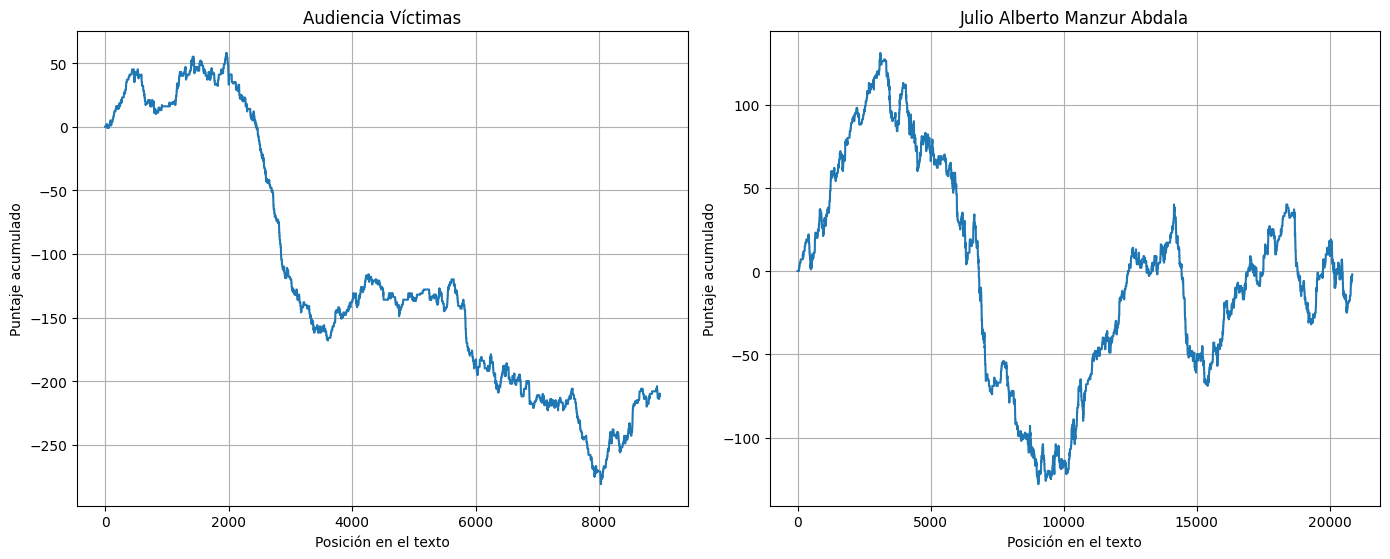

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

n = len(tendencias_afinn)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

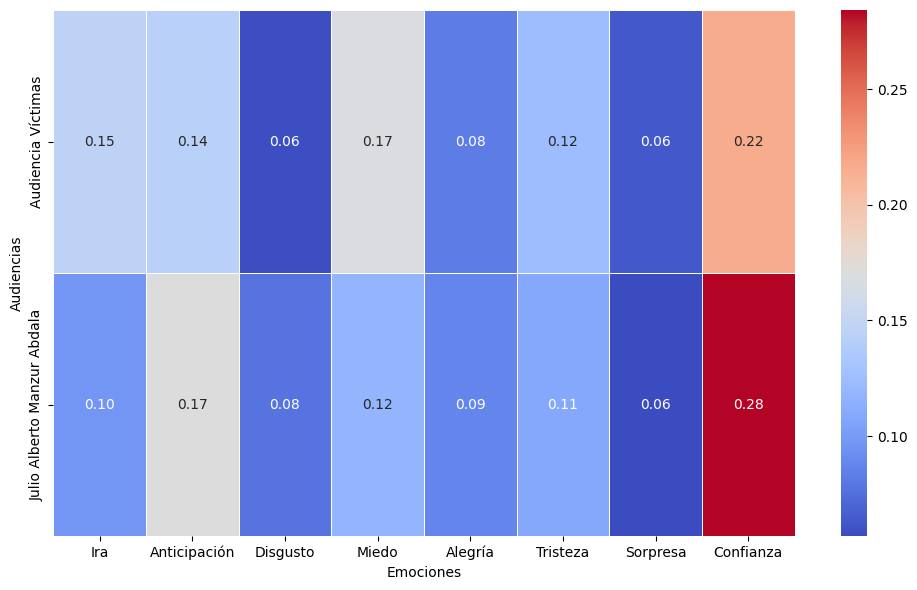

In [22]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Audiencias')
plt.tight_layout()
plt.show()

# **RED BASICA**

In [23]:
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----------------------- Cálculo de métricas --------------------------------------------
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'Audiencia Víctimas': 837 nodos, 3065 aristas (componente gigante).
Grafo 'Julio Alberto Manzur Abdala': 1413 nodos, 7764 aristas (componente gigante).

Métricas
                             num_nodos  num_aristas  densidad  grado_promedio  \
Audiencia Víctimas                 837         3065  0.008760        7.323775   
Julio Alberto Manzur Abdala       1413         7764  0.007783       10.989384   

                             transitividad_global  assortatividad_grado  \
Audiencia Víctimas                       0.134122             -0.073447   
Julio Alberto Manzur Abdala              0.149544             -0.133827   

                             diametro  longitud_media_camino  \
Audiencia Víctimas                  9               3.397143   
Julio Alberto Manzur Abdala         8               3.073455   

                             betweenness_media  betweenness_max  \
Audiencia Víctimas                    0.002878         0.227559   
Julio Alberto Manzur Abdala        

In [24]:
top10_grado_por_red

{'Audiencia Víctimas':               nodo  grado  porcentaje_grado
 2          victima    180          0.029364
 18   compareciente     92          0.015008
 144        persona     88          0.014356
 54    jurisdiccion     81          0.013214
 66        justicia     78          0.012724
 29   investigacion     73          0.011909
 30          crimen     71          0.011582
 16         version     70          0.011419
 250     territorio     70          0.011419
 232        publico     68          0.011093,
 'Julio Alberto Manzur Abdala':              nodo  grado  porcentaje_grado
 106       cordoba    285          0.018354
 196  departamento    270          0.017388
 25        persona    249          0.016036
 118      politico    230          0.014812
 372       reunion    211          0.013588
 143   paramilitar    207          0.013331
 312     preguntar    171          0.011012
 462         creer    161          0.010368
 241       mancuso    143          0.009209
 16        

In [25]:
### Primer término por centralidad y grado máx.
def max_info(df, col):
    idx = df[col].idxmax()
    return df.loc[idx, col], df.loc[idx, "nodo"]

redes_metrics = {}
centralidades_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    G = nx.Graph()
    G.add_edges_from(datos["skipgramas_filtrados"])

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo":        list(G_gigante.nodes()),
        "grado":       [grados[n]      for n in G_gigante.nodes()],
        "betweenness": [betweenness[n] for n in G_gigante.nodes()],
        "closeness":   [closeness[n]   for n in G_gigante.nodes()],
        "eigenvector": [eigenvector[n] for n in G_gigante.nodes()]
    })
    centralidades_por_red[nombre] = df_centralidad

    grado_max,  nodo_grado_max = max_info(df_centralidad, "grado")
    betw_max,   nodo_betw_max  = max_info(df_centralidad, "betweenness")
    close_max,  nodo_close_max = max_info(df_centralidad, "closeness")
    eig_max,    nodo_eig_max   = max_info(df_centralidad, "eigenvector")

    redes_metrics[nombre] = {
        "num_nodos":             num_nodos,
        "grado_max":             grado_max,       "nodo_grado_max":       nodo_grado_max,
        "betweenness_max":       betw_max,         "nodo_betweenness_max": nodo_betw_max,
        "closeness_max":         close_max,        "nodo_closeness_max":   nodo_close_max,
        "eigenvector_max":       eig_max,          "nodo_eigenvector_max": nodo_eig_max,
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print(df_metrics)

Grafo 'Audiencia Víctimas': 837 nodos, 3065 aristas (componente gigante).
Grafo 'Julio Alberto Manzur Abdala': 1413 nodos, 7764 aristas (componente gigante).
                             num_nodos  grado_max nodo_grado_max  \
Audiencia Víctimas                 837        180        victima   
Julio Alberto Manzur Abdala       1413        285        cordoba   

                             betweenness_max nodo_betweenness_max  \
Audiencia Víctimas                  0.227559              victima   
Julio Alberto Manzur Abdala         0.102437              cordoba   

                             closeness_max nodo_closeness_max  \
Audiencia Víctimas                0.497915            victima   
Julio Alberto Manzur Abdala       0.517975            cordoba   

                             eigenvector_max nodo_eigenvector_max  
Audiencia Víctimas                  0.328535              victima  
Julio Alberto Manzur Abdala         0.220419              cordoba  
